## Imports and Reproducible Setup

This cell imports the ODT generator, DLGN-SF model, and training utility from the package.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from first_experiment.odt import generate_cob_odt_data
from first_experiment.dlgn import DLGNSF
from first_experiment.training import (
    TrainConfig,
    evaluate_dlgn_sf,
    set_seed,
    train_dlgn_sf,
)
import copy

# Paper-1-style synthetic setting
DIM = 100
DEPTH = 5
N_TRAIN = 80_000

# Separate seeds for reproducibility control
DATA_SEED = 3178
INIT_SEED = 3178
TRAIN_SEED_PHASE1 = 3178
TRAIN_SEED_PHASE2 = 3179
TRAIN_SEED_ONE_PHASE = 3178

# DLGN-SF architecture from milestone plan
HIDDEN_DIMS = [16] * 5  # current notebook setting
BETA = 11.0

## Generate COB-ODT Data


In [2]:
x, y, tree, meta = generate_cob_odt_data(
    num_data=2 * N_TRAIN,
    dim=DIM,
    depth=DEPTH,
    seed=DATA_SEED,
    threshold=0.0,
)

x_train = x[:N_TRAIN]
y_train = y[:N_TRAIN]
x_eval = x[N_TRAIN:]
y_eval = y[N_TRAIN:]

print("x_train shape:", x_train.shape)
print("y_train shape:", y_train.shape)
print("meta:", meta)
print("label counts:", dict(zip(*np.unique(y_train, return_counts=True))))

x_train shape: (80000, 100)
y_train shape: (80000,)
meta: {'num_requested': 160000, 'num_kept': 160000, 'num_pruned': 0, 'dim': 100, 'depth': 5, 'num_internal_nodes': 31, 'num_leaf_nodes': 32, 'threshold': 0.0, 'seed': 3178}
label counts: {np.int8(-1): np.int64(39970), np.int8(1): np.int64(40030)}


##  Train DLGN-SF on the Synthetic Data -- Two-phase

This cell trains the model using Adam + BCE-with-logits via `train_dlgn_sf`.
Two phases: phase 1 uses gating regularization, phase 2 uses no regularization.
For a fair comparison with one-phase training, total epochs are split equally across phases.

In [3]:
from torch.optim import lr_scheduler


TOTAL_EPOCHS = 2000
PHASE1_EPOCHS = TOTAL_EPOCHS // 2
PHASE2_EPOCHS = TOTAL_EPOCHS - PHASE1_EPOCHS

set_seed(INIT_SEED)
model_two_phase = DLGNSF(
    input_dim=DIM,
    hidden_dims=HIDDEN_DIMS,
    beta=BETA,
    bias=False,
    value_input_mode="ones",  # default in current code
    gating_weight_scale=1.0,
    value_weight_scale=1.0,
)

train_cfg_phase1 = TrainConfig(
    epochs=PHASE1_EPOCHS,
    lr=0.001,
    batch_size=N_TRAIN // 500,
    seed=TRAIN_SEED_PHASE1,
    device="cpu",        # switch to "cuda" if available and desired
    snapshot_epochs=tuple(range(0, PHASE1_EPOCHS + 1, 20)),
    show_progress=True,
    weight_decay_gating=2e-4,
    weight_decay_value=0.0,
    lr_scheduler = "cosine",
    lr_scheduler_eta_min_ratio = 0.2,
)

out_two_phase_phase1 = train_dlgn_sf(
    model=model_two_phase,
    x_train=x_train,
    y_train=y_train,
    config=train_cfg_phase1,
)

train_cfg_phase2 = TrainConfig(
    epochs=PHASE2_EPOCHS,
    lr=0.001,
    batch_size=N_TRAIN // 500,
    seed=TRAIN_SEED_PHASE2,
    device="cpu",        # switch to "cuda" if available and desired
    snapshot_epochs=tuple(range(0, PHASE2_EPOCHS + 1, 20)),
    show_progress=True,
    weight_decay_gating=0.0,
    weight_decay_value=0.0,
    lr_scheduler = "cosine",
    lr_scheduler_eta_min_ratio = 0.2,

)

out_two_phase_phase2 = train_dlgn_sf(
    model=out_two_phase_phase1["model"],
    x_train=x_train,
    y_train=y_train,
    config=train_cfg_phase2,
)


Training DLGN-SF:   0%|          | 0/1001 [00:00<?, ?it/s]

Training DLGN-SF:   0%|          | 0/1001 [00:00<?, ?it/s]

### Compare with one-phase no-regularization run

In [4]:
set_seed(INIT_SEED)
model_one_phase = DLGNSF(
    input_dim=DIM,
    hidden_dims=HIDDEN_DIMS,
    beta=BETA,
    bias=False,
    value_input_mode="ones",  # default in current code
    gating_weight_scale=1.0,
    value_weight_scale=1.0,
)

train_cfg_one_phase = TrainConfig(
    epochs=TOTAL_EPOCHS,
    lr=0.001,
    batch_size=N_TRAIN // 500,
    seed=TRAIN_SEED_ONE_PHASE,
    device="cpu",        # switch to "cuda" if available and desired
    snapshot_epochs=tuple(range(0, TOTAL_EPOCHS + 1, 20)),
    show_progress=True,
    weight_decay_gating=0.0,
    weight_decay_value=0.0,
    lr_scheduler = "cosine",
    lr_scheduler_eta_min_ratio = 0.2,
)

out_one_phase = train_dlgn_sf(
    model=model_one_phase,
    x_train=x_train,
    y_train=y_train,
    config=train_cfg_one_phase,
)



Training DLGN-SF:   0%|          | 0/2001 [00:00<?, ?it/s]

## Variable reference for downstream analysis

Use these variables for metric tables, plots, and alignment analysis:

- `out_one_phase`: Output dict from one-phase no-regularization training (`train_dlgn_sf`).
- `train_cfg_one_phase`: `TrainConfig` used for `out_one_phase`.


- `out_two_phase_phase1`: Output dict from phase-1 training (with gating regularization).
- `train_cfg_phase1`: `TrainConfig` for two-phase phase 1.
- `out_two_phase_phase2`: Output dict from phase-2 training (no regularization, initialized from phase 1 model).
- `train_cfg_phase2`: `TrainConfig` for two-phase phase 2.


## Metrics at each snapshot epoch (train vs test)



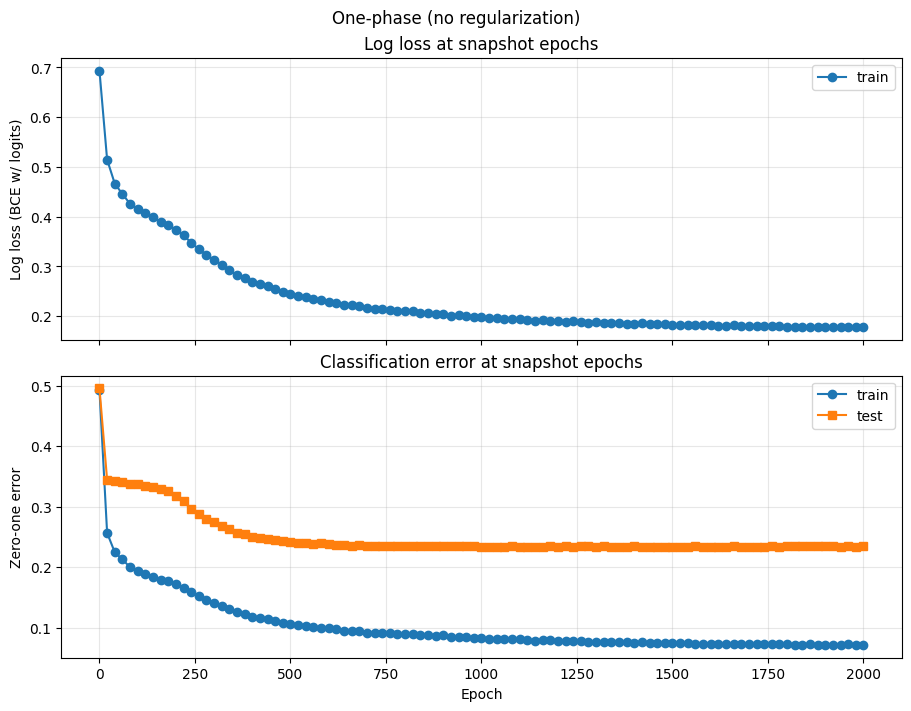

In [9]:
# Choose which run to analyze:
#   "one_phase", "two_phase_phase1", "two_phase_phase2"
RUN_MODE = "one_phase"

run_map = {
    "one_phase": {
        "out": out_one_phase,
        "train_cfg": train_cfg_one_phase,
        "title": "One-phase (no regularization)",
    },
    "two_phase_phase1": {
        "out": out_two_phase_phase1,
        "train_cfg": train_cfg_phase1,
        "title": "Two-phase: phase 1 (gating regularization)",
    },
    "two_phase_phase2": {
        "out": out_two_phase_phase2,
        "train_cfg": train_cfg_phase2,
        "title": "Two-phase: phase 2 (no regularization)",
    },
}

if RUN_MODE not in run_map:
    raise ValueError(f"RUN_MODE must be one of {list(run_map.keys())}, got {RUN_MODE!r}")

out = run_map[RUN_MODE]["out"]
train_cfg = run_map[RUN_MODE]["train_cfg"]
FIG_SUPTITLE = run_map[RUN_MODE]["title"]

fig, axes = plt.subplots(2, 1, figsize=(9, 7), sharex=True, constrained_layout=True)
fig.suptitle(FIG_SUPTITLE)


checkpoint_snapshots = out["checkpoint_snapshots"]
DEVICE = train_cfg.device  # e.g. "cpu" or "cuda"

eval_model = copy.deepcopy(out["model"]).to(DEVICE)

epochs_sorted = sorted(checkpoint_snapshots.keys())

train_log_loss = []
test_log_loss = []
train_err = []
test_err = []

for ep in epochs_sorted:
    eval_model.load_state_dict(checkpoint_snapshots[ep])
    eval_model.to(DEVICE)

    m_tr = evaluate_dlgn_sf(
        model=eval_model, x_eval=x_train, y_eval=y_train, device=DEVICE
    )
    m_te = evaluate_dlgn_sf(
        model=eval_model, x_eval=x_eval, y_eval=y_eval, device=DEVICE
    )

    train_log_loss.append(m_tr["log_loss"])
    test_log_loss.append(m_te["log_loss"])
    train_err.append(m_tr["zero_one_loss"])
    test_err.append(m_te["zero_one_loss"])

epochs_sorted = np.asarray(epochs_sorted)



axes[0].plot(epochs_sorted, train_log_loss, marker="o", label="train")
# axes[0].plot(epochs_sorted, test_log_loss, marker="s", label="test")
axes[0].set_ylabel("Log loss (BCE w/ logits)")
axes[0].set_title("Log loss at snapshot epochs")
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(epochs_sorted, train_err, marker="o", label="train")
axes[1].plot(epochs_sorted, test_err, marker="s", label="test")
axes[1].set_ylabel("Zero-one error")
axes[1].set_xlabel("Epoch")
axes[1].set_title("Classification error at snapshot epochs")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.show()


## Scatter at a chosen training epoch (from checkpoint snapshots)

Set `EPOCH` to an integer that was included in `TrainConfig(snapshot_epochs=...)`.
If that epoch is missing from `out["checkpoint_snapshots"]`, re-run training with that epoch listed in `snapshot_epochs`.
Gating vectors are recovered with `effective_gating_weights_from_checkpoint`.

/var/folders/pd/w8bnb5rs76g9lp6n7cpjt8ch0000gn/T/ipykernel_21852/3762810416.py:41: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("tab20", num_odt_nodes)


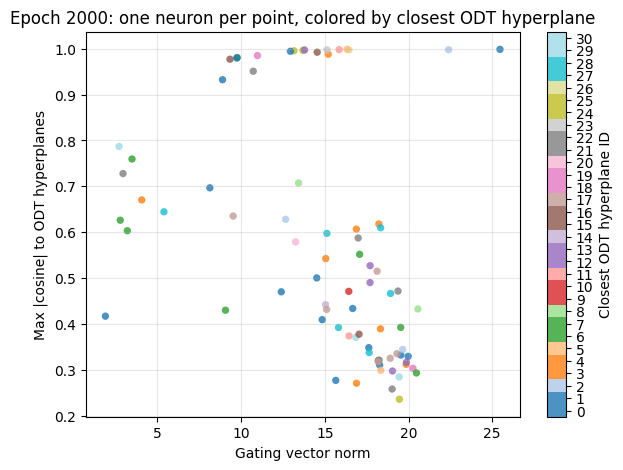

In [10]:
# ---- user argument ----
EPOCH = train_cfg.snapshot_epochs[-1]   # change this

# ---- expected variables from earlier cells ----
# out = train_dlgn_sf(...)
# tree = COB-ODT tree used for data
from first_experiment.training import effective_gating_weights_from_checkpoint

checkpoint_snapshots = out["checkpoint_snapshots"]
odt_normals = tree.w_list

if EPOCH not in checkpoint_snapshots:
    raise KeyError(
        f"No snapshot for epoch {EPOCH}. Available: {sorted(checkpoint_snapshots.keys())}"
    )

def stack_gating_numpy(gating_list):
    return np.concatenate([np.asarray(w) for w in gating_list], axis=0)

def neuron_alignment_stats(gating_vectors, odt_normals):
    g_norm = np.linalg.norm(gating_vectors, axis=1, keepdims=True)
    u_norm = np.linalg.norm(odt_normals, axis=1, keepdims=True)
    g_norm = np.maximum(g_norm, 1e-12)
    u_norm = np.maximum(u_norm, 1e-12)

    g_unit = gating_vectors / g_norm
    u_unit = odt_normals / u_norm

    cos_abs = np.abs(g_unit @ u_unit.T)
    closest_id = np.argmax(cos_abs, axis=1)
    max_cos = cos_abs[np.arange(cos_abs.shape[0]), closest_id]
    norms = g_norm.squeeze(1)
    return norms, max_cos, closest_id

g_epoch = stack_gating_numpy(
    effective_gating_weights_from_checkpoint(out["model"], checkpoint_snapshots[EPOCH])
)
norms, maxcos, closest = neuron_alignment_stats(g_epoch, odt_normals)

num_odt_nodes = odt_normals.shape[0]
cmap = plt.cm.get_cmap("tab20", num_odt_nodes)

plt.figure(figsize=(7, 5))
sc = plt.scatter(
    norms,
    maxcos,
    c=closest,
    cmap=cmap,
    s=28,
    alpha=0.8,
    edgecolors="none",
)

plt.xlabel("Gating vector norm")
plt.ylabel("Max |cosine| to ODT hyperplanes")
plt.title(f"Epoch {EPOCH}: one neuron per point, colored by closest ODT hyperplane")
plt.grid(alpha=0.3)

cbar = plt.colorbar(sc, ticks=np.arange(num_odt_nodes))
cbar.set_label("Closest ODT hyperplane ID")
plt.clim(-0.5, num_odt_nodes - 0.5)

plt.show()